In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║           SECTION 1 — SETUP & LOAD DATA                 ║
# ╚══════════════════════════════════════════════════════════╝

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings for beautiful plots
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.edgecolor']   = '#444466'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#333355'
plt.rcParams['grid.alpha']       = 0.4

PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff']

# ── Load Dataset ──
path = kagglehub.dataset_download("hassan06/nslkdd")

#definign the 43 columns of nslkdd
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

df = pd.read_csv(f"{path}/KDDTrain+.txt", names=columns)

# ── Quick Summary ──
print("=" * 50)
print("       NSL-KDD DATASET — LOADED SUCCESSFULLY")
print("=" * 50)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Labels  : {df['label'].nunique()} unique classes")
print("=" * 50)
display(df.head(10))

Using Colab cache for faster access to the 'nslkdd' dataset.
       NSL-KDD DATASET — LOADED SUCCESSFULLY
  Rows    : 125,973
  Columns : 43
  Labels  : 23 unique classes


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


in this section I mapped every individual attack label into one of four categories — DoS, Probing, R2L, and U2R — plus Normal traffic.

we have 23 attacks in 4 categories

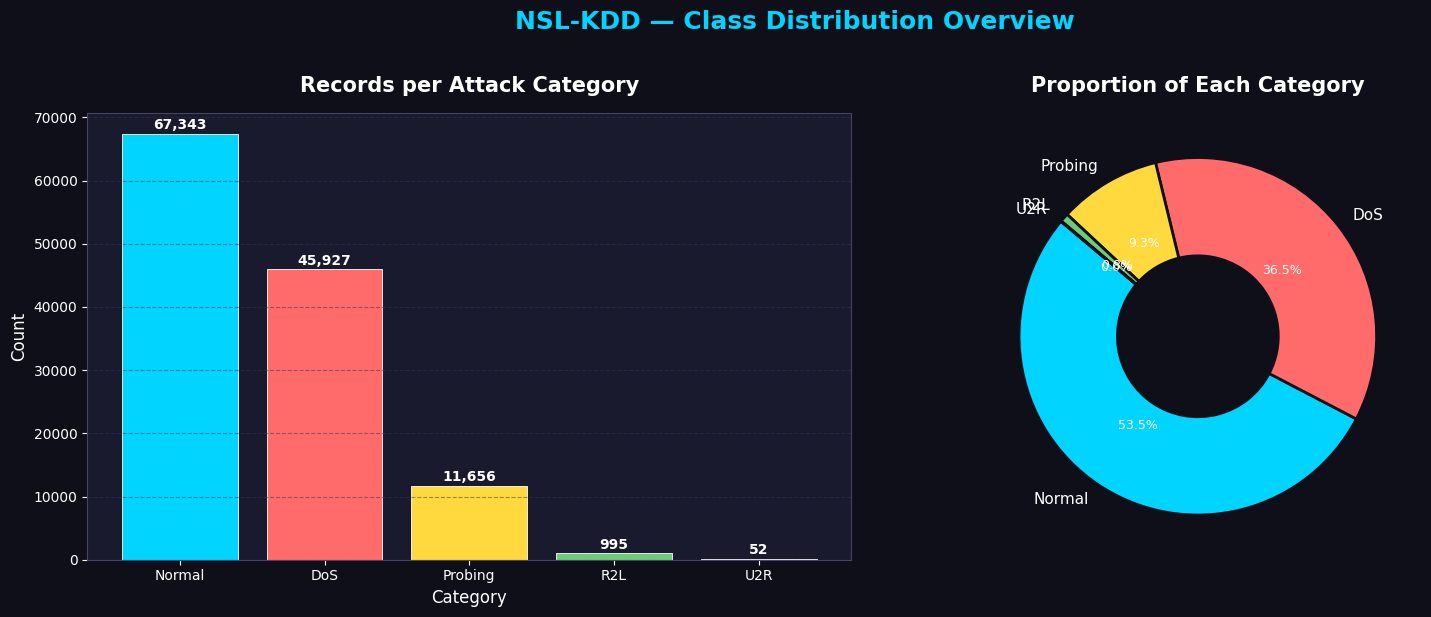


Detailed counts:
  Normal      67,343  (53.5%)
  DoS         45,927  (36.5%)
  Probing     11,656  (9.3%)
  R2L            995  (0.8%)
  U2R             52  (0.0%)


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║       SECTION 2 — ATTACK CATEGORY DISTRIBUTION          ║
# ╚══════════════════════════════════════════════════════════╝


# Map every label to its attack category
category_map = {
    'normal'          : 'Normal',
    'neptune'         : 'DoS', 'smurf' : 'DoS', 'back'     : 'DoS',
    'teardrop'        : 'DoS', 'pod'   : 'DoS', 'land'     : 'DoS',
    'satan'           : 'Probing', 'ipsweep' : 'Probing',
    'portsweep'       : 'Probing', 'nmap'    : 'Probing',
    'warezclient'     : 'R2L', 'warezmaster' : 'R2L',
    'guess_passwd'    : 'R2L', 'ftp_write'   : 'R2L',
    'imap'            : 'R2L', 'phf'         : 'R2L',
    'multihop'        : 'R2L', 'spy'         : 'R2L',
    'buffer_overflow' : 'U2R', 'rootkit'     : 'U2R',
    'loadmodule'      : 'U2R', 'perl'        : 'U2R',
}

df['category'] = df['label'].map(category_map).fillna('Other')

cat_counts = df['category'].value_counts().reindex(
    ['Normal', 'DoS', 'Probing', 'R2L', 'U2R']
)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')

# Left: bar chart
bars = axes[0].bar(cat_counts.index, cat_counts.values,
                   color=PALETTE, edgecolor='white', linewidth=0.6)
axes[0].set_title('Records per Attack Category', fontsize=15,
                  fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')

# Right: donut chart
wedges, texts, autotexts = axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    colors=PALETTE,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='#0f0f1a', linewidth=2),
    textprops=dict(color='white', fontsize=11)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Proportion of Each Category', fontsize=15,
                  fontweight='bold', color='white', pad=15)

plt.suptitle('NSL-KDD — Class Distribution Overview',
             fontsize=18, fontweight='bold', color='#00d4ff', y=1.02)
plt.tight_layout()
plt.show()

print("\nDetailed counts:")
for cat, cnt in cat_counts.items():
    pct = cnt / len(df) * 100
    print(f"  {cat:<10} {cnt:>7,}  ({pct:.1f}%)")

Protocol and Service Analyisis

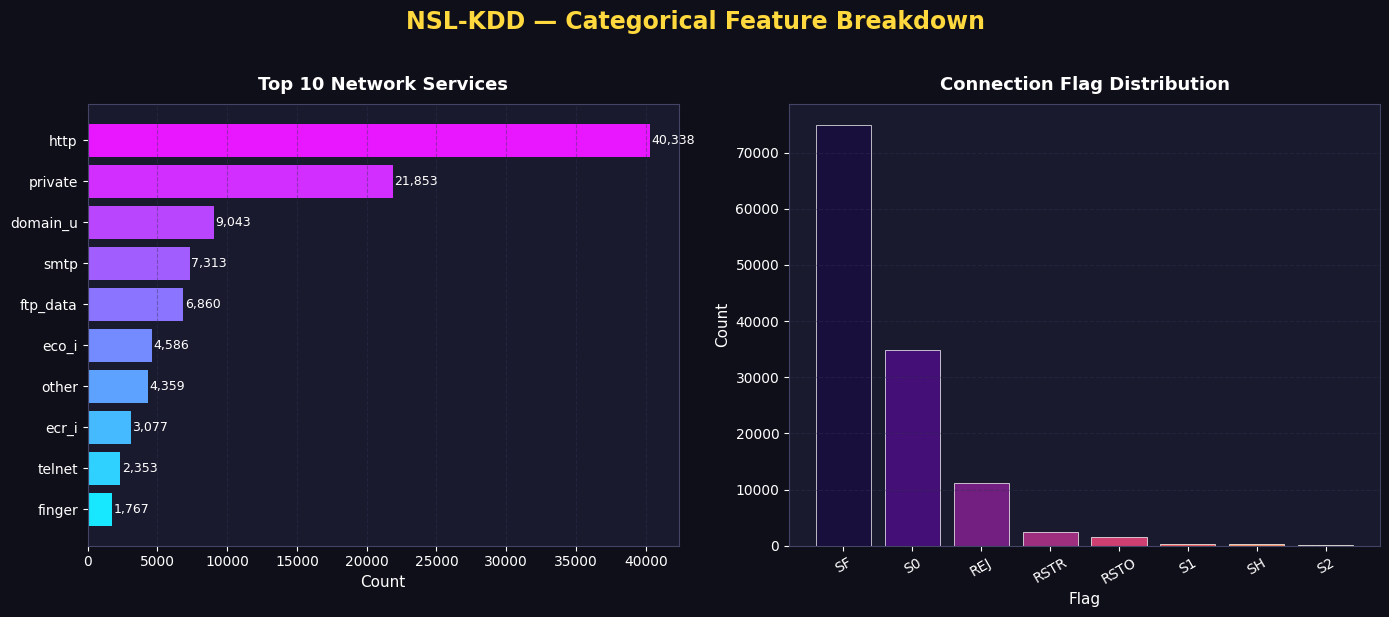

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║       SECTION 3 — SERVICE & FLAG ANALYSIS               ║
# ╚══════════════════════════════════════════════════════════╝

# ── Top 10 services ──
top_services = df['service'].value_counts().head(10)

# ── Flag distribution ──
flag_counts = df['flag'].value_counts().head(8)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')

# Left: top services
bars2 = axes[0].barh(top_services.index[::-1],
                     top_services.values[::-1],
                     color=sns.color_palette('cool', 10))
axes[0].set_title('Top 10 Network Services', fontsize=13,
                  fontweight='bold', color='white', pad=10)
axes[0].set_xlabel('Count', fontsize=11)
for bar, val in zip(bars2, top_services.values[::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', color='white', fontsize=9)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)

# Right: flag distribution
axes[1].bar(flag_counts.index, flag_counts.values,
            color=sns.color_palette('magma', len(flag_counts)),
            edgecolor='white', linewidth=0.5)
axes[1].set_title('Connection Flag Distribution', fontsize=13,
                  fontweight='bold', color='white', pad=10)
axes[1].set_xlabel('Flag', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('NSL-KDD — Categorical Feature Breakdown',
             fontsize=17, fontweight='bold', color='#ffd93d', y=1.02)
plt.tight_layout()
plt.show()

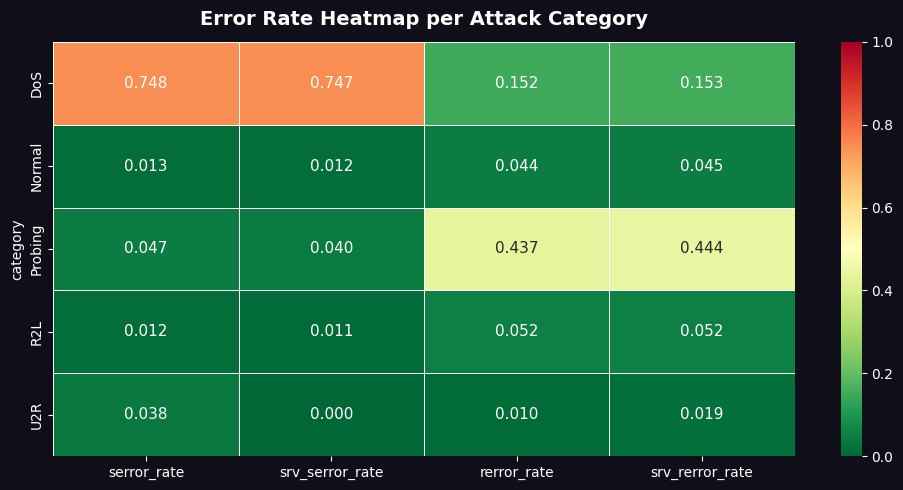

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║    SECTION 4 — ERROR RATE FINGERPRINTS PER CATEGORY     ║
# ╚══════════════════════════════════════════════════════════╝

# Calculate error rates per category
error_rate_cols = ['serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate']
error_table = df.groupby('category')[error_rate_cols].mean()

# Error Rate Heatmap per Attack Category
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')

sns.heatmap(
    error_table,
    ax=ax,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    annot_kws={'size': 11},
    vmin=0, vmax=1
)
ax.set_title('Error Rate Heatmap per Attack Category',
             fontsize=14, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white', labelsize=10)
plt.tight_layout()
plt.show()



serror_rate          = SYN Error Rate

srv_serror_rate      = SYN Error Rate (Same Service)

rerror_rate          = Rejected Connection Rate

srv_rerror_rate      = Rejected Rate (Same Service)

dst_host_serror_rate = SYN Error Rate (Destination Host)

dst_host_rerror_rate = Rejected Rate (Destination Host)


**SYN error = connection started but never finished**

👉 Sign of DoS attack

**REJ error = connection was rejected**

👉 Sign of Probing attack


next step : using ml to labeling the data
20% testing
80% training

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║       SECTION 5 — PREPROCESSING FOR ML                  ║
# ╚══════════════════════════════════════════════════════════╝

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df_ml = df.copy()

le_protocol = LabelEncoder()
le_service  = LabelEncoder()
le_flag     = LabelEncoder()
le_label    = LabelEncoder()

df_ml['protocol_type'] = le_protocol.fit_transform(df_ml['protocol_type'])
df_ml['service']       = le_service.fit_transform(df_ml['service'])
df_ml['flag']          = le_flag.fit_transform(df_ml['flag'])
df_ml['category_enc']  = le_label.fit_transform(df_ml['category'])

feature_cols = [c for c in df_ml.columns
                if c not in ['label', 'category', 'category_enc', 'difficulty_level']]

X = df_ml[feature_cols]
y = df_ml['category_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Preprocessing complete.")
print(f"  Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"  Features : {X_train.shape[1]}")
print(f"  Classes  : {le_label.classes_}")


Preprocessing complete.
  Train : 100,778  |  Test : 25,195
  Features : 41
  Classes  : ['DoS' 'Normal' 'Probing' 'R2L' 'U2R']



Training Random Forest …
  Accuracy: 0.9990


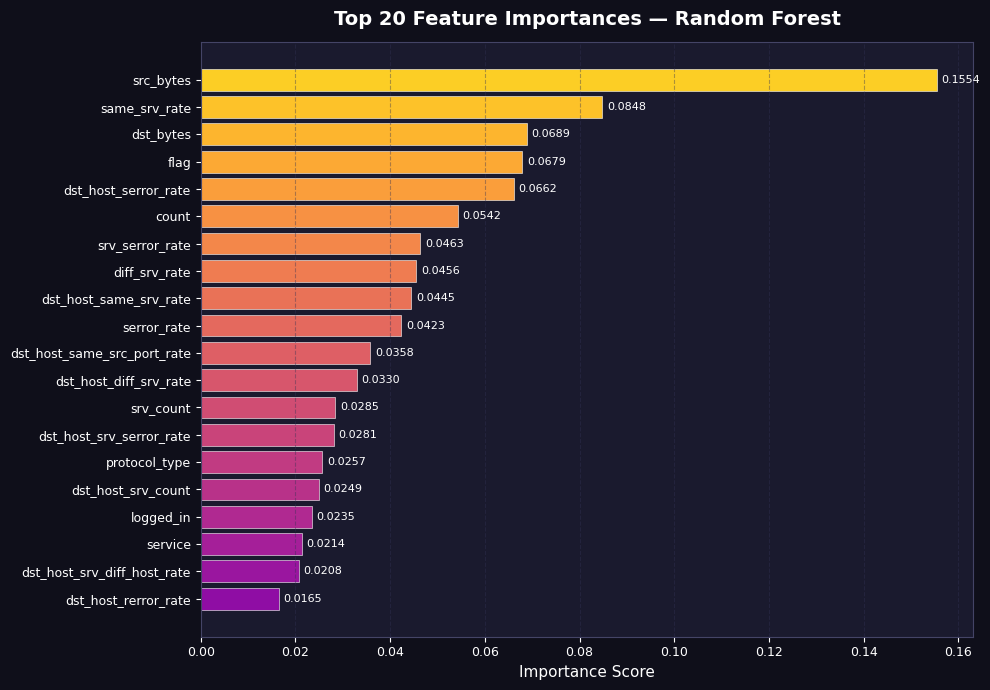


Top 10 most important features:
  src_bytes                           0.1554
  same_srv_rate                       0.0848
  dst_bytes                           0.0689
  flag                                0.0679
  dst_host_serror_rate                0.0662
  count                               0.0542
  srv_serror_rate                     0.0463
  diff_srv_rate                       0.0456
  dst_host_same_srv_rate              0.0445
  serror_rate                         0.0423


In [ ]:


# ╔══════════════════════════════════════════════════════════╗
# ║    SECTION 6 — RANDOM FOREST + FEATURE IMPORTANCE       ║
# ╚══════════════════════════════════════════════════════════╝

print("\nTraining Random Forest …")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"  Accuracy: {rf_acc:.4f}")

importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20       = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f0f1a')

colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top20)))
bars   = ax.barh(top20.index, top20.values, color=colors,
                 edgecolor='white', linewidth=0.4)
ax.set_title('Top 20 Feature Importances — Random Forest',
             fontsize=14, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Importance Score', fontsize=11)
ax.tick_params(colors='white', labelsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
for bar, val in zip(bars, top20.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', color='white', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
for feat, score in importances.nlargest(10).items():
    print(f"  {feat:<35} {score:.4f}")



  Classification Report — Random Forest
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
     Probing       1.00      0.99      1.00      2331
         R2L       1.00      0.97      0.98       199
         U2R       0.89      0.80      0.84        10

    accuracy                           1.00     25195
   macro avg       0.98      0.95      0.96     25195
weighted avg       1.00      1.00      1.00     25195


  Classification Report — Logistic Regression
              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      9186
      Normal       0.96      0.98      0.97     13469
     Probing       0.90      0.83      0.87      2331
         R2L       0.70      0.67      0.69       199
         U2R       0.71      0.50      0.59        10

    accuracy                           0.97     25195
   macro avg       0.85      0.80      0.82

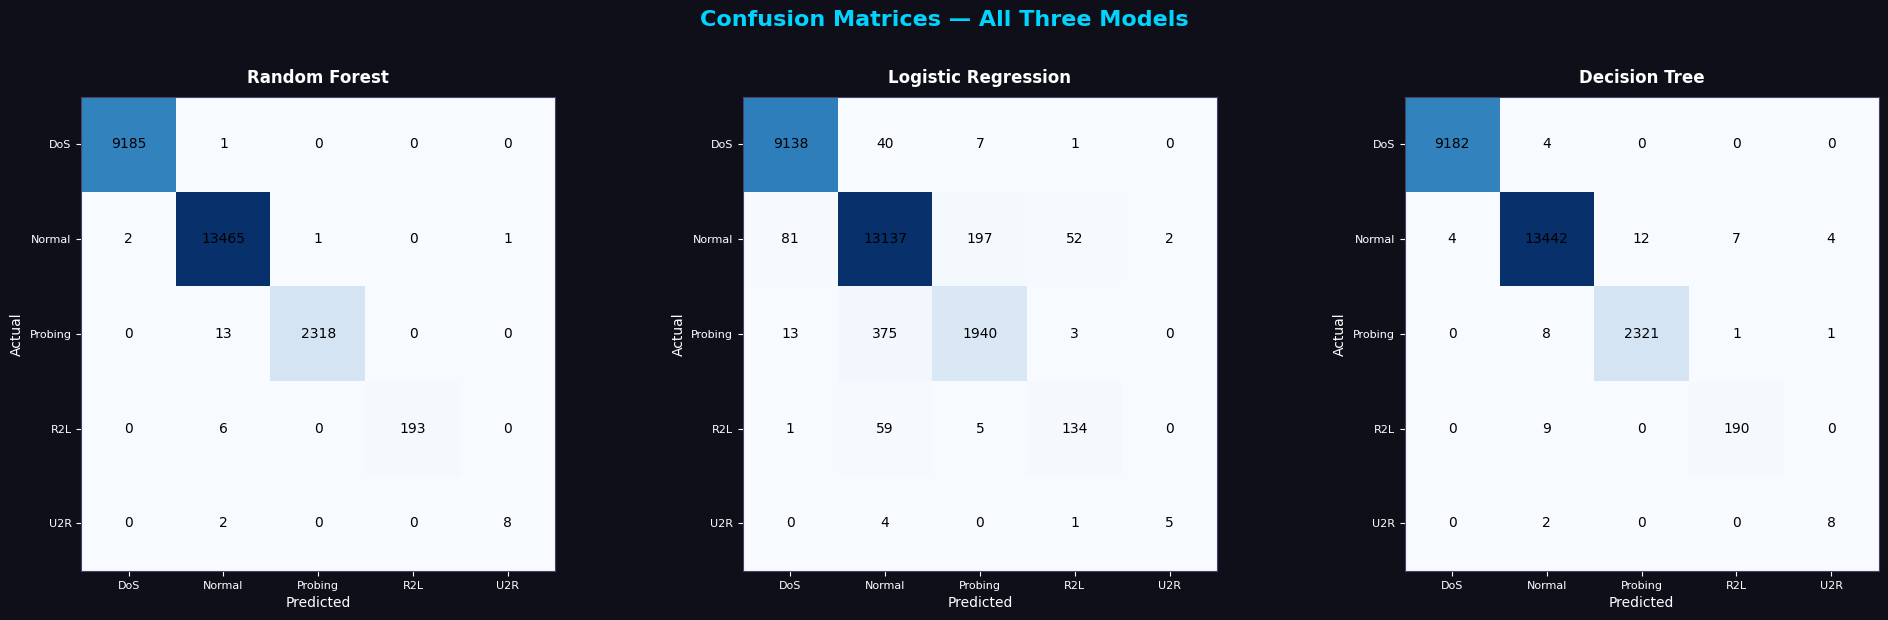

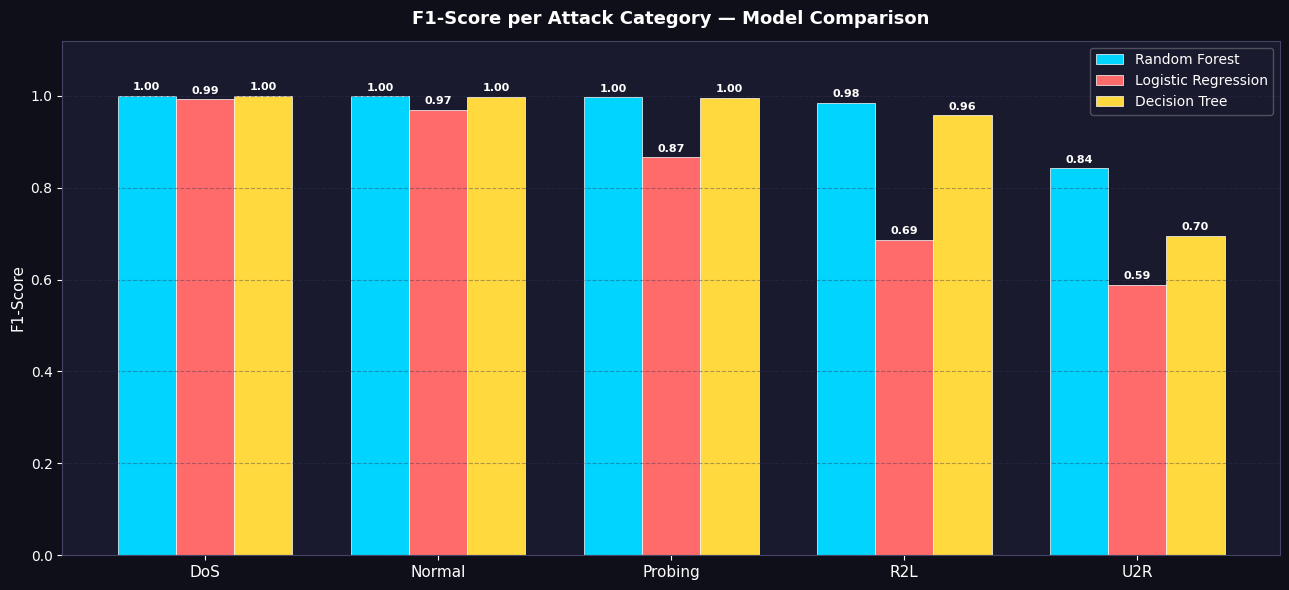

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║   SECTION 7 — CLASSIFICATION REPORT & CONFUSION MATRIX  ║
# ╚══════════════════════════════════════════════════════════╝

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_names = le_label.classes_   # ['DoS', 'Normal', 'Probing', 'R2L', 'U2R']

models = {
    'Random Forest'      : (rf,  X_test,    y_test),
    'Logistic Regression': (lr,  X_test_sc, y_test),
    'Decision Tree'      : (dt,  X_test,    y_test),
}

# ── 1. Classification Report for each model ──
for model_name, (model, X_t, y_t) in models.items():
    y_pred = model.predict(X_t)
    print(f"\n{'='*55}")
    print(f"  Classification Report — {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_t, y_pred, target_names=class_names))


# ── 2. Confusion Matrices (side by side) ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0f0f1a')

for ax, (model_name, (model, X_t, y_t)) in zip(axes, models.items()):
    y_pred = model.predict(X_t)
    cm     = confusion_matrix(y_t, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model_name, fontsize=12, fontweight='bold',
                 color='white', pad=10)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_xlabel('Predicted', color='white')
    ax.set_ylabel('Actual',    color='white')
    ax.title.set_color('white')
    # make text inside cells readable
    for text in disp.text_.ravel():
        text.set_color('black')

plt.suptitle('Confusion Matrices — All Three Models',
             fontsize=16, fontweight='bold', color='#00d4ff', y=1.02)
plt.tight_layout()
plt.show()


# ── 3. F1-Score Comparison Bar Chart ──
from sklearn.metrics import f1_score

f1_data = {}
for model_name, (model, X_t, y_t) in models.items():
    y_pred = model.predict(X_t)
    f1s    = f1_score(y_t, y_pred, average=None, labels=le_label.transform(class_names))
    f1_data[model_name] = f1s

f1_df = pd.DataFrame(f1_data, index=class_names)

x     = np.arange(len(class_names))
width = 0.25
colors = ['#00d4ff', '#ff6b6b', '#ffd93d']

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f0f1a')

for i, (model_name, color) in enumerate(zip(models.keys(), colors)):
    bars = ax.bar(x + i * width, f1_df[model_name], width,
                  label=model_name, color=color,
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, f1_df[model_name]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom',
                color='white', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('F1-Score per Attack Category — Model Comparison',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_ylabel('F1-Score', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10, framealpha=0.3, labelcolor='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()


Training Logistic Regression …
  Logistic Regression overall accuracy: 0.9666

Training Decision Tree …
  Decision Tree overall accuracy: 0.9979

── Overall Multi-Class Accuracy ──
                     Accuracy
Model                        
Random Forest        0.998968
Logistic Regression  0.966620
Decision Tree        0.997936


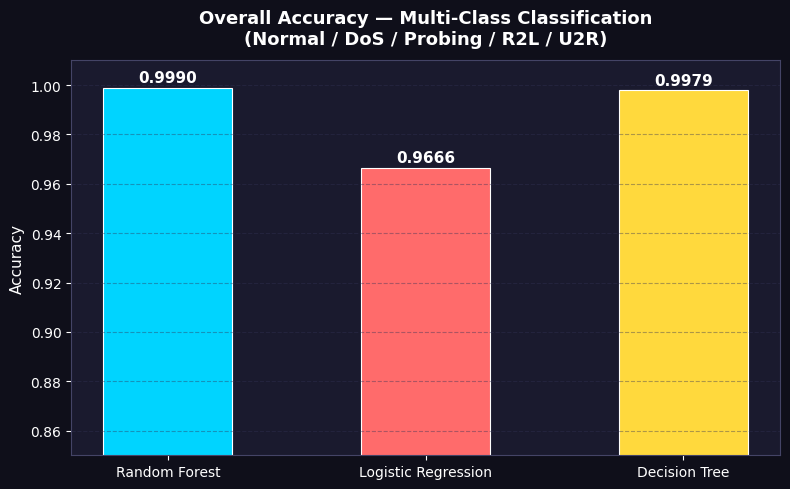

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 8 — OVERALL MODEL COMPARISON TABLE             ║
# ╚══════════════════════════════════════════════════════════╝

print("\nTraining Logistic Regression …")
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))
print(f"  Logistic Regression overall accuracy: {lr_acc:.4f}")

print("\nTraining Decision Tree …")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"  Decision Tree overall accuracy: {dt_acc:.4f}")

# ── Summary table ──
overall_results = pd.DataFrame({
    'Model'   : ['Random Forest', 'Logistic Regression', 'Decision Tree'],
    'Accuracy': [rf_acc, lr_acc, dt_acc]
}).set_index('Model')

print("\n── Overall Multi-Class Accuracy ──")
print(overall_results.to_string())

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0f0f1a')

model_names = overall_results.index.tolist()
accs        = overall_results['Accuracy'].values
bar_colors  = ['#00d4ff', '#ff6b6b', '#ffd93d']

bars = ax.bar(model_names, accs, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)

ax.set_ylim(0.85, 1.01)
ax.set_title('Overall Accuracy — Multi-Class Classification\n(Normal / DoS / Probing / R2L / U2R)',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_ylabel('Accuracy', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', color='white',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║         SECTION 9 — INTERPRETATION & RECOMMENDATIONS    ║
# ╚══════════════════════════════════════════════════════════╝

print("""
==========================================================
   INTERPRETATION & RECOMMENDATIONS
==========================================================

── Why Random Forest Performs Best ──
Random Forest builds hundreds of decision trees and combines
their votes. This ensemble approach reduces overfitting and
handles the high-dimensional NSL-KDD features (41 features)
better than a single tree or linear model.

── Why U2R Is the Hardest Category ──
U2R (User-to-Root) attacks have very few samples in the dataset
(less than 0.1% of records). This extreme class imbalance means
models see very few examples during training, leading to low
recall on U2R. High accuracy on U2R binary classification is
MISLEADING: a model that always predicts "Not U2R" would still
be ~99.9% accurate. This is called the Accuracy Paradox.

── Recommendations  ──
1. DEPLOY Random Forest as the primary detection engine —
   it achieves the best F1-scores across DoS, Probing, and Normal.

2. PRIORITIZE recall over precision for attack categories —
   in cybersecurity, a missed attack (false negative) is far more
   costly than a false alarm (false positive).

3. ADDRESS U2R class imbalance using techniques such as:
   - SMOTE (Synthetic Minority Oversampling Technique)
   - Adjusting class_weight='balanced' in the classifier
   - Collecting more U2R attack samples

4. RETRAIN the model periodically — network attack patterns
   evolve rapidly, and a model trained on older data will degrade
   in real-world performance over time.

5. COMBINE ML with rule-based systems — ML catches novel attacks,
   while signature-based tools catch known malware efficiently.
""")


   INTERPRETATION & RECOMMENDATIONS

── Why Random Forest Performs Best ──
Random Forest builds hundreds of decision trees and combines
their votes. This ensemble approach reduces overfitting and
handles the high-dimensional NSL-KDD features (41 features)
better than a single tree or linear model.

── Why U2R Is the Hardest Category ──
U2R (User-to-Root) attacks have very few samples in the dataset
(less than 0.1% of records). This extreme class imbalance means
models see very few examples during training, leading to low
recall on U2R. High accuracy on U2R binary classification is
MISLEADING: a model that always predicts "Not U2R" would still
be ~99.9% accurate. This is called the Accuracy Paradox.

── Recommendations  ──
1. DEPLOY Random Forest as the primary detection engine —
   it achieves the best F1-scores across DoS, Probing, and Normal.

2. PRIORITIZE recall over precision for attack categories —
   in cybersecurity, a missed attack (false negative) is far more
   costly than 